In [1]:
# !pip install cantools
# !unzip CANDID.zip

In [2]:
import pandas as pd
import cantools

# --- 1. Load Data ---
can_log_path = 'logs/3_2012 Subaru Impreza/lights/3_lights_CAN.log'


# The CAN log is whitespace-separated: (timestamp) can0 ID#Payload
df_can = pd.read_csv(can_log_path, delim_whitespace=True, header=None, names=['timestamp', 'bus', 'raw_frame'])

# --- 2. Parse the CAN Data ---
# Split the raw_frame into ID and Payload
frame_parts = df_can['raw_frame'].str.split('#', expand=True)
df_can['id'] = frame_parts[0]
df_can['payload'] = frame_parts[1]

# Clean up the timestamp by removing parentheses
df_can['timestamp'] = df_can['timestamp'].str.strip('()').astype(float).astype(int)

print("CAN data loaded and parsed:")
print(df_can.head(),df_can.shape)



CAN data loaded and parsed:
    timestamp   bus             raw_frame   id           payload
0  1730100556  can0  002#0010700B8B000000  002  0010700B8B000000
1  1730100556  can0  372#0000000000000000  372  0000000000000000
2  1730100556  can0  140#0008004000001A01  140  0008004000001A01
3  1730100556  can0  0D0#F3FF000000000200  0D0  F3FF000000000200
4  1730100556  can0          0D1#00000002  0D1          00000002 (141884, 5)


/tmp/ipykernel_411/2328196692.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_can = pd.read_csv(can_log_path, delim_whitespace=True, header=None, names=['timestamp', 'bus', 'raw_frame'])


In [3]:
print(min(df_can['timestamp']),max(df_can['timestamp']))

print(df_can[df_can['timestamp']==1730100570][df_can['id']=='152'].head(5))

print(df_can[df_can['timestamp']==1730100571][df_can['id']=='152'].head(10))

print(df_can[df_can['timestamp']==1730100572][df_can['id']=='152'].head(5))

print(df_can[df_can['timestamp']==1730100581][df_can['id']=='152'].head(5))

print(df_can[df_can['timestamp']==1730100582][df_can['id']=='152'].head(5))


print(df_can[df_can['timestamp']==1730100592][df_can['id']=='152'].head(5))

print(df_can[df_can['timestamp']==1730100593][df_can['id']=='152'].head(5))

/tmp/ipykernel_411/177755447.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(df_can[df_can['timestamp']==1730100570][df_can['id']=='152'].head(5))
/tmp/ipykernel_411/177755447.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(df_can[df_can['timestamp']==1730100571][df_can['id']=='152'].head(10))


1730100556 1730100681
        timestamp   bus             raw_frame   id           payload
15281  1730100570  can0  152#F124000000000880  152  F124000000000880
15303  1730100570  can0  152#F134000000000880  152  F134000000000880
15324  1730100570  can0  152#F144000000000880  152  F144000000000880
15349  1730100570  can0  152#F154000000000880  152  F154000000000880
15371  1730100570  can0  152#F164000000000880  152  F164000000000880
        timestamp   bus             raw_frame   id           payload
16415  1730100571  can0  152#F144000000000884  152  F144000000000884
16437  1730100571  can0  152#F154000000000884  152  F154000000000884
16458  1730100571  can0  152#F164000000000884  152  F164000000000884
16483  1730100571  can0  152#F174000000000884  152  F174000000000884
16505  1730100571  can0  152#F184000000000884  152  F184000000000884
16529  1730100571  can0  152#F19400000000088C  152  F19400000000088C
16552  1730100571  can0  152#F1A400000000088C  152  F1A400000000088C
16573  17301

/tmp/ipykernel_411/177755447.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(df_can[df_can['timestamp']==1730100572][df_can['id']=='152'].head(5))
/tmp/ipykernel_411/177755447.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(df_can[df_can['timestamp']==1730100581][df_can['id']=='152'].head(5))
/tmp/ipykernel_411/177755447.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(df_can[df_can['timestamp']==1730100582][df_can['id']=='152'].head(5))
/tmp/ipykernel_411/177755447.py:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(df_can[df_can['timestamp']==1730100592][df_can['id']=='152'].head(5))
/tmp/ipykernel_411/177755447.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(df_can[df_can['timestamp']==1730100593][df_can['id']=='152'].head(5))


Generating histogram...


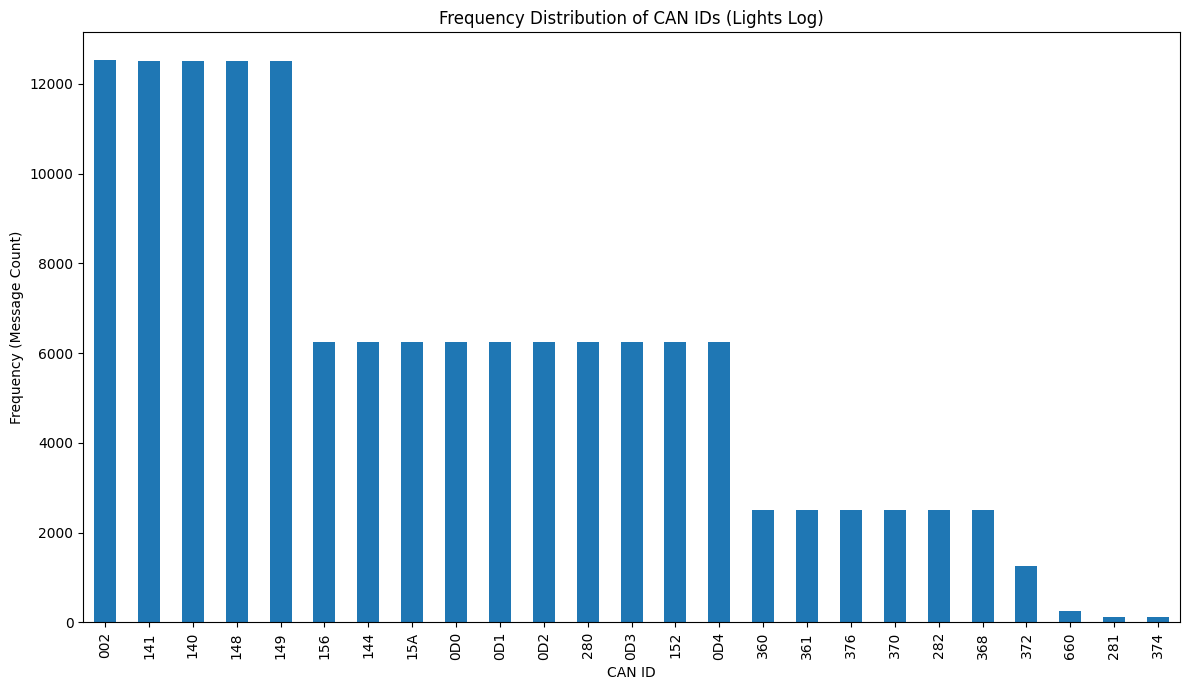

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Assumes 'df_can' is already loaded in your environment ---
# If not, you must load it first, e.g.:
# df_can = pd.read_csv('labeled_lights_data.csv')

# --- 1. Get Frequency Counts ---
# This is the core of the histogram:
# It counts how many times each unique ID appears in the log.
id_counts = df_can['id'].value_counts()

# --- 2. Sort for Readability ---
# Sorting from most frequent to least makes the chart much cleaner.
id_counts_sorted = id_counts.sort_values(ascending=False)

# --- 3. Plot the Histogram (Bar Chart) ---
print("Generating histogram...")

plt.figure(figsize=(12, 7))  # Make the figure larger
id_counts_sorted.plot(kind='bar')

# --- 4. Add Labels and Title ---
plt.title('Frequency Distribution of CAN IDs (Lights Log)')
plt.xlabel('CAN ID')
plt.ylabel('Frequency (Message Count)')
plt.xticks(rotation=90)  # Rotate ID labels so they don't overlap
plt.tight_layout()      # Adjust plot to prevent labels from being cut off

# --- 5. Display the Plot ---
plt.show()

# To save it to a file instead of showing it, use:
# plt.savefig('can_id_histogram.png')
# print("Histogram saved as 'can_id_histogram.png'")

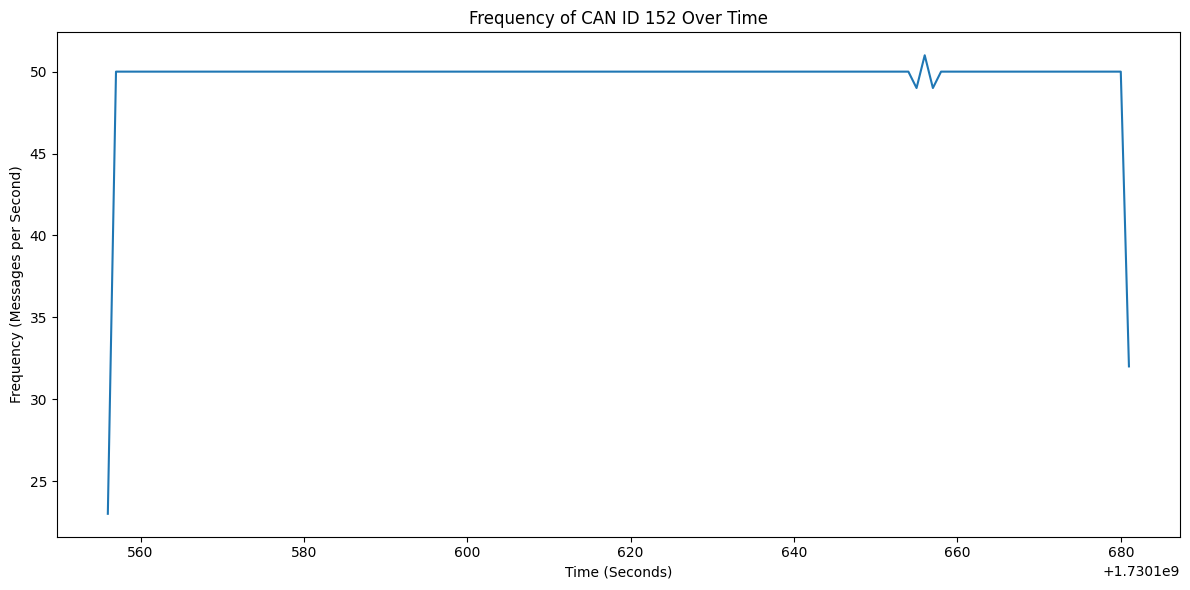

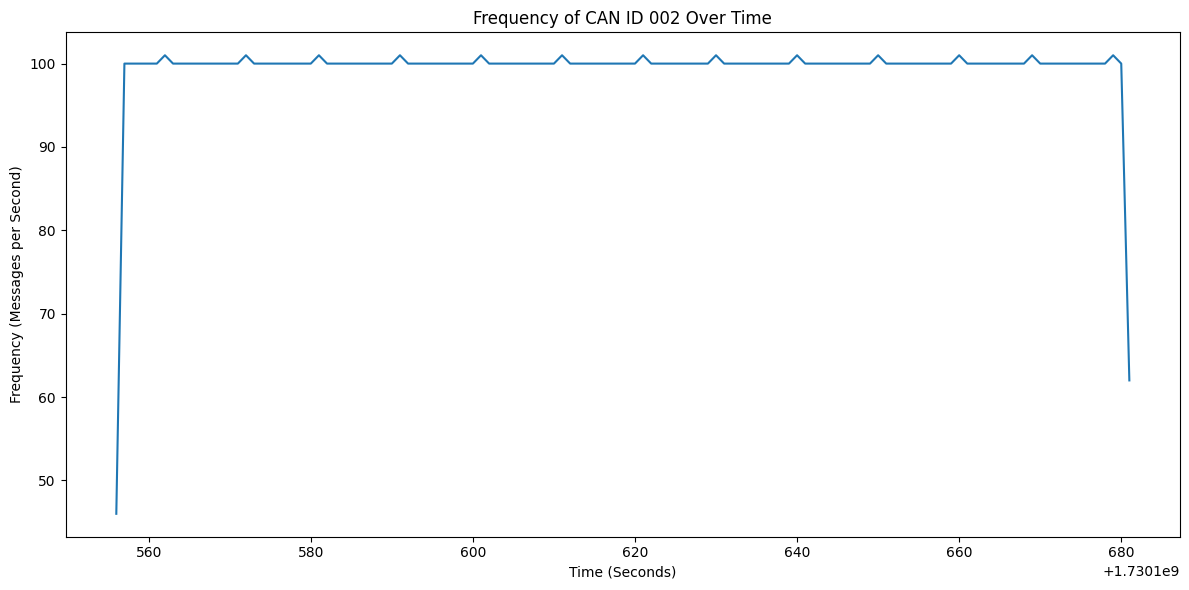

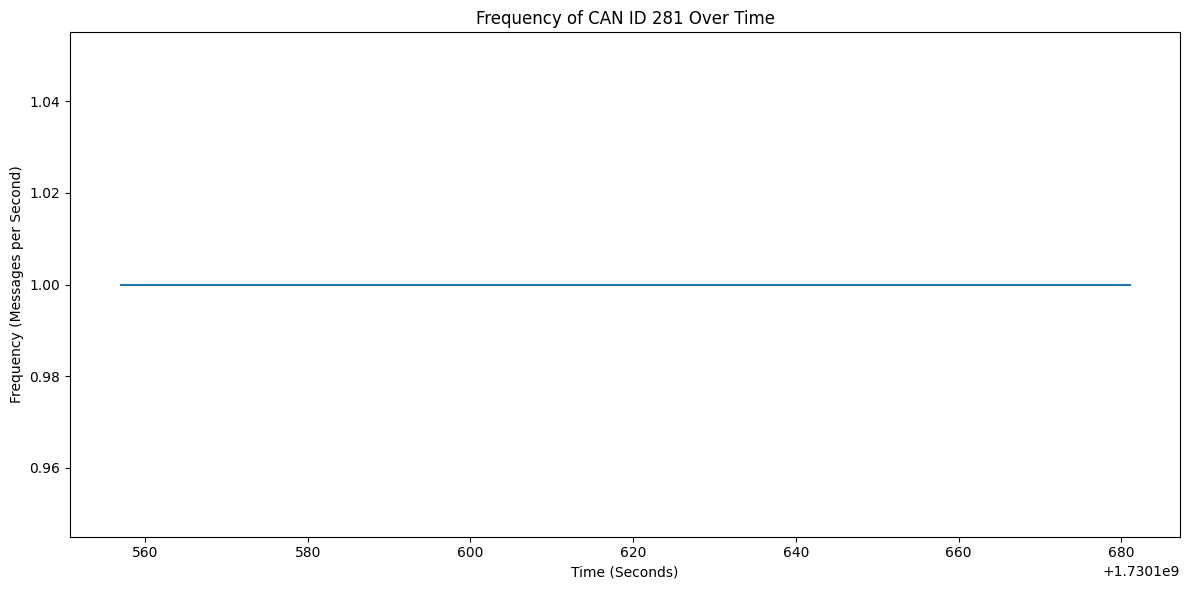

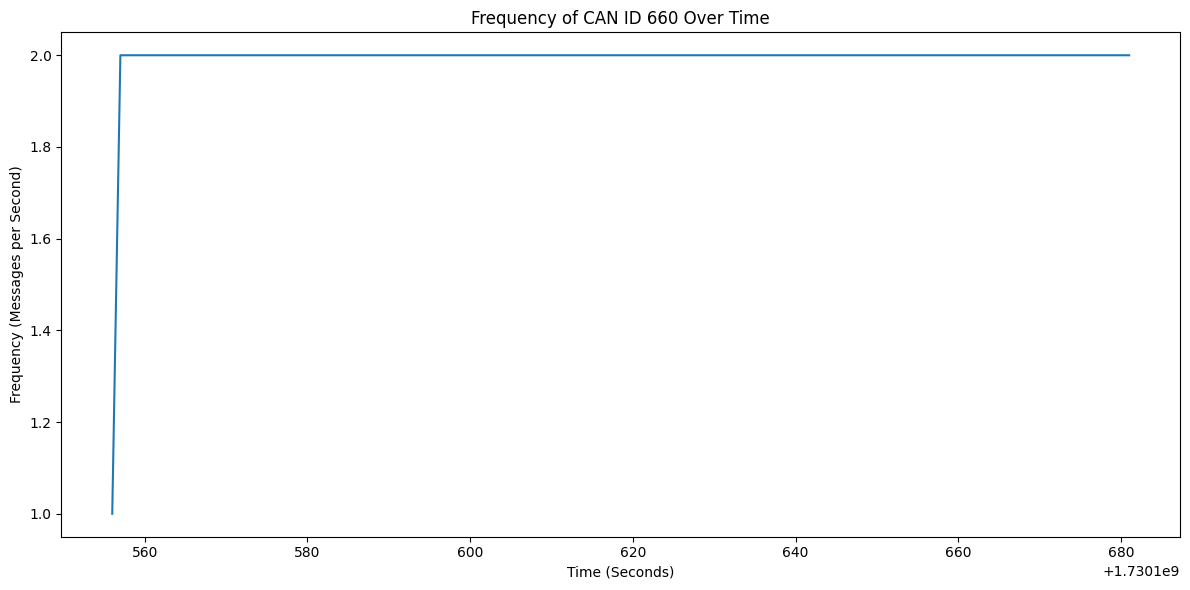

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Load the CAN Log ---
# This assumes your df_can is already loaded.
# If not, uncomment the lines below to load it.
# 
# can_log_path = 'D:/Downloads/CANdid/logs/3_2012 Subaru Impreza/lights/3_lights_CAN.log'
# df_can = pd.read_csv(can_log_path, delim_whitespace=True, header=None, 
#                      names=['timestamp', 'bus', 'raw_frame'])
# frame_parts = df_can['raw_frame'].str.split('#', expand=True)
# df_can['id'] = frame_parts[0]
# df_can['timestamp'] = df_can['timestamp'].str.strip('()').astype(float)

df_152 = df_can[df_can['id'] == '152'].copy()

df_152['time_second'] = df_152['timestamp'].round()

frequency_counts = df_152.groupby('time_second').size()

plt.figure(figsize=(12, 6))

# Use a line plot to show frequency over time
frequency_counts.plot(kind='line')

plt.title('Frequency of CAN ID 152 Over Time')
plt.xlabel('Time (Seconds)')
plt.ylabel('Frequency (Messages per Second)')
plt.tight_layout()
plt.show()

df_002 = df_can[df_can['id'] == '002'].copy()

df_002['time_second'] = df_002['timestamp'].round()

frequency_counts = df_002.groupby('time_second').size()

plt.figure(figsize=(12, 6))

# Use a line plot to show frequency over time
frequency_counts.plot(kind='line')

plt.title('Frequency of CAN ID 002 Over Time')
plt.xlabel('Time (Seconds)')
plt.ylabel('Frequency (Messages per Second)')
plt.tight_layout()

# --- 2. Filter for ID 152 ---
df_281 = df_can[df_can['id'] == '281'].copy()

df_281['time_second'] = df_281['timestamp'].round()

frequency_counts = df_281.groupby('time_second').size()

plt.figure(figsize=(12, 6))

# Use a line plot to show frequency over time
frequency_counts.plot(kind='line')

plt.title('Frequency of CAN ID 281 Over Time')
plt.xlabel('Time (Seconds)')
plt.ylabel('Frequency (Messages per Second)')
plt.tight_layout()

# --- 2. Filter for ID 152 ---
df_660 = df_can[df_can['id'] == '660'].copy()

df_660['time_second'] = df_660['timestamp'].round()

frequency_counts = df_660.groupby('time_second').size()

plt.figure(figsize=(12, 6))

# Use a line plot to show frequency over time
frequency_counts.plot(kind='line')

plt.title('Frequency of CAN ID 660 Over Time')
plt.xlabel('Time (Seconds)')
plt.ylabel('Frequency (Messages per Second)')
plt.tight_layout()



In [6]:
dbc_path = '_subaru_preglobal_2015.dbc' # UPDATE THIS PATH

# Load the DBC file
db = cantools.database.load_file(dbc_path)

In [7]:
annot_log_path = 'logs/3_2012 Subaru Impreza/lights/3_lights_annot.log'
df_log= pd.read_csv(annot_log_path, header=None,names=['timestamp', 'action'])
print(df_log.head(10),df_log.shape)

    timestamp         action
0  1730100571      Lights On
1  1730100582     Lights Off
2  1730100593      Lights On
3  1730100604     Lights Off
4  1730100615      Lights On
5  1730100626   Highbeams On
6  1730100637  Highbeams Off
7  1730100648   Highbeams On
8  1730100659  Highbeams Off
9  1730100670     Lights Off (10, 2)


In [8]:
for index, row in df_log.iterrows():
    annot_timestamp = row['timestamp']
    driver_action = row['action'] # Assuming 'action' is the column name
    
    print('====================================')
    print(driver_action)
    print(df_can[df_can['timestamp']==annot_timestamp-1][df_can['id']=='152'].head(20))
    print(df_can[df_can['timestamp']==annot_timestamp][df_can['id']=='152'].head(20))


Lights On
        timestamp   bus             raw_frame   id           payload
15281  1730100570  can0  152#F124000000000880  152  F124000000000880
15303  1730100570  can0  152#F134000000000880  152  F134000000000880
15324  1730100570  can0  152#F144000000000880  152  F144000000000880
15349  1730100570  can0  152#F154000000000880  152  F154000000000880
15371  1730100570  can0  152#F164000000000880  152  F164000000000880
15395  1730100570  can0  152#F174000000000880  152  F174000000000880
15418  1730100570  can0  152#F184000000000880  152  F184000000000880
15439  1730100570  can0  152#F194000000000880  152  F194000000000880
15463  1730100570  can0  152#F1A4000000000880  152  F1A4000000000880
15485  1730100570  can0  152#F1B4000000000880  152  F1B4000000000880
15509  1730100570  can0  152#F1C4000000000880  152  F1C4000000000880
15531  1730100570  can0  152#F1D4000000000880  152  F1D4000000000880
15552  1730100570  can0  152#F1E4000000000880  152  F1E4000000000880
15576  1730100570  can0 

/tmp/ipykernel_411/3237745646.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(df_can[df_can['timestamp']==annot_timestamp-1][df_can['id']=='152'].head(20))
/tmp/ipykernel_411/3237745646.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(df_can[df_can['timestamp']==annot_timestamp][df_can['id']=='152'].head(20))
/tmp/ipykernel_411/3237745646.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(df_can[df_can['timestamp']==annot_timestamp-1][df_can['id']=='152'].head(20))
/tmp/ipykernel_411/3237745646.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(df_can[df_can['timestamp']==annot_timestamp][df_can['id']=='152'].head(20))
/tmp/ipykernel_411/3237745646.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(df_can[df_can['timestamp']==annot_timestamp-1][df_can['id']=='152'].head(20))
/tmp/ipykernel

In [9]:
def hex_to_binary_string(hex_str, num_bits=64):
    """Converts a hex string to a zero-padded binary string."""
    # Ensure the hex string is not empty
    if not hex_str:
        return '0' * num_bits
    
    # Convert hex to an integer, then to a binary string (removes '0b' prefix)
    binary_str = bin(int(hex_str, 16))[2:]
    
    # Pad with leading zeros to ensure it's the correct length (e.g., 64 bits for 8 bytes)
    return binary_str.zfill(num_bits)

In [10]:
# --- 3. Isolate Event ---
event_timestamp = 1730100582.0 # From the annot.log file

# Define the time window
time_window = 1.0 # seconds

df_before = df_can[
    (df_can['timestamp'] >= event_timestamp - time_window) &
    (df_can['timestamp'] < event_timestamp)
]

df_after = df_can[
    (df_can['timestamp'] >= event_timestamp) &
    (df_can['timestamp'] < event_timestamp + time_window)
]

# --- 4. Find Differences ---
# Get the last message for each ID before the event
state_before = df_before.drop_duplicates(subset=['id'], keep='last').set_index('id')['payload'].to_dict()

# Find IDs that changed their payload right after the event
changed_ids = {}

for index, row in df_after.iterrows():
    can_id = row['id']
    current_payload = row['payload']

    if can_id in state_before and can_id not in changed_ids:
        if state_before[can_id] != current_payload:
            changed_ids[can_id] = {
                'before': state_before[can_id],
                'after': current_payload
            }

# print("\n--- Found Changed Payloads ---")
# for can_id, change in changed_ids.items():
#     print(f"ID: {can_id}")
#     print(f"  Payload Before: {change['before']}")
#     print(f"  Payload After:  {change['after']}")

#     # --- 5. Decode with DBC ---
#         # Convert hex payload to byte array for decoding
#         payload_bytes_before = bytes.fromhex(change['before'])
#         payload_bytes_after = bytes.fromhex(change['after'])

#         decoded_before = db.decode_message(can_id, payload_bytes_before)
#         decoded_after = db.decode_message(can_id, payload_bytes_after)

#         print("  Decoded (Before):", decoded_before)
#         print("  Decoded (After): ", decoded_after)
#     except Exception as e:
#         print(f"  Could not decode ID {can_id}: {e}")
# --- NEW ANALYSIS BLOCK ---
print("\n--- Found Changed Payloads & Analyzing Bit Transitions ---")
for can_id, change in changed_ids.items():
    before_hex = change['before']
    after_hex = change['after']
    
    print(f"ID: {can_id} | Before: {before_hex} | After: {after_hex}")
    
    # Convert payloads to binary strings for comparison
    before_binary = hex_to_binary_string(before_hex)
    after_binary = hex_to_binary_string(after_hex)
    
    found_transition = False
    for bit_index in range(64):
        bit_before = before_binary[bit_index]
        bit_after = after_binary[bit_index]
        
        if bit_before != bit_after:
            found_transition = True
            print(f"  >> Bit {bit_index}: Flipped from {bit_before} -> {bit_after}")
            
    if not found_transition:
        print("  Payloads differ, but no bit transitions found? Check padding/length.")

    # --- Correlate with DBC (as before, but now with bit context) ---
    print("  --- DBC Correlation ---")
    try:
        # Get the message definition from the DBC
        # Note: DBC frame IDs are integers, so we convert from hex
        message_def = db.get_message_by_frame_id(int(can_id, 16))
        print(f"  DBC Message: '{message_def.name}'")
        
        # Check which signal corresponds to the "hot bit"
        for signal in message_def.signals:
            # We need to find if our hot bit_index is part of this signal
            # This is a simplified check; CAN bits can be complex (Motorola vs Intel format)
            # but for many simple signals, this works.
            if signal.start <= bit_index < (signal.start + signal.length):
                 print(f"  ✅ Bit {bit_index} is part of signal: '{signal.name}'")

    except KeyError:
        print(f"  No definition found in DBC for ID {can_id}")
    except Exception as e:
        print(f"  Could not process ID {can_id}: {e}")


--- Found Changed Payloads & Analyzing Bit Transitions ---
ID: 140 | Before: 0009004000001A01 | After: 000A004000001A01
  >> Bit 14: Flipped from 0 -> 1
  >> Bit 15: Flipped from 1 -> 0
  --- DBC Correlation ---
  DBC Message: 'Throttle'
  ✅ Bit 63 is part of signal: 'Signal4'
ID: 361 | Before: 000947DF6540776F | After: 000947DF66407A6F
  >> Bit 38: Flipped from 0 -> 1
  >> Bit 39: Flipped from 1 -> 0
  >> Bit 52: Flipped from 0 -> 1
  >> Bit 53: Flipped from 1 -> 0
  >> Bit 55: Flipped from 1 -> 0
  --- DBC Correlation ---
  No definition found in DBC for ID 361
ID: 15A | Before: 811A000000020020 | After: 821A000000020020
  >> Bit 6: Flipped from 0 -> 1
  >> Bit 7: Flipped from 1 -> 0
  --- DBC Correlation ---
  No definition found in DBC for ID 15A
ID: 148 | Before: 0E1300804100FF01 | After: 0E1400804100FF01
  >> Bit 13: Flipped from 0 -> 1
  >> Bit 14: Flipped from 1 -> 0
  >> Bit 15: Flipped from 1 -> 0
  --- DBC Correlation ---
  DBC Message: 'Transmission'
ID: 002 | Before: 0010

In [11]:
import numpy as np
from sklearn.cluster import DBSCAN

target_id = '152'
all_payloads_hex = df_can[df_can['id'] == target_id]['payload'].tolist()

# 2. Build the matrix X
X_list = []
for hex_str in all_payloads_hex:
    # Convert hex string to 64-bit binary string
    binary_str = hex_to_binary_string(hex_str, 64)
    
    # Convert binary string '0101...' to a list of integers [0, 1, 0, 1, ...]
    bit_vector = [int(bit) for bit in binary_str]
    X_list.append(bit_vector)

# Convert to a NumPy array, which scikit-learn needs
X = np.array(X_list)

print(f"Built matrix X with shape: {X.shape}") 
# Output will be something like: (5000, 64)

# 3. Run DBSCAN on X
db = DBSCAN(eps=.01, min_samples=20, metric='hamming')
clusters = db.fit_predict(X)

Built matrix X with shape: (6254, 64)


In [12]:
print(clusters)

[ 0  1  2 ... 11 12 13]


In [13]:
target_id = '152'
all_payloads_hex = df_can[df_can['id'] == target_id]['payload'].tolist()

X_list = []
for hex_str in all_payloads_hex:
    binary_str = hex_to_binary_string(hex_str, 64)
    bit_vector = [int(bit) for bit in binary_str]
    X_list.append(bit_vector)

X = np.array(X_list)

db = DBSCAN(eps=0.01, min_samples=20, metric='hamming') # Keep eps low
clusters = db.fit_predict(X)

print(f"Clusters for ID {target_id}:")
# print([i for i in clusters])

Clusters for ID 152:


In [14]:
# --- 1. Define the Counter Mask (CORRECTED) ---
# This mask zeros out the high nibble of Byte 1 (bits 12-15)
COUNTER_MASK = int('0000FFFFFFFFFFFF', 16) 

# --- 2. Isolate and Mask Payloads ---
target_id = '152'
all_payloads_hex = df_can[df_can['id'] == target_id]['payload'].tolist()
all_payloads_timestamps = df_can[df_can['id'] == target_id]['timestamp'].tolist()
X_list = []

prev_hex=hex(0)

for i,hex_str in enumerate(all_payloads_hex):
    payload_int = int(hex_str[:16], 16)
    
    # Apply the mask to remove the counter
    masked_int = payload_int & COUNTER_MASK
    # Convert the *masked* int back to a binary string
    binary_str = bin(masked_int)[2:].zfill(64)
    
    bit_vector = [int(bit) for bit in binary_str]
    if hex(masked_int) != prev_hex:
        print(hex(masked_int))
        print(all_payloads_timestamps[i])
        
    X_list.append(bit_vector)
    prev_hex=hex(masked_int)
    
X = np.array(X_list)

# --- 3. Run DBSCAN on Masked Data ---
db = DBSCAN(eps=0.01, min_samples=20, metric='hamming')
clusters = db.fit_predict(X)

print(f"Clusters for ID {target_id} (Masked with CORRECT mask):")
print(clusters)
print(f"Unique clusters found: {np.unique(clusters)}")



0x880
1730100556
0x884
1730100570
0x88c
1730100571
0x884
1730100581
0x880
1730100581
0x884
1730100592
0x88c
1730100592
0x884
1730100603
0x880
1730100604
0x884
1730100615
0x88c
1730100615
0x89c
1730100626
0x88c
1730100637
0x89c
1730100648
0x88c
1730100659
0x884
1730100670
0x880
1730100670
Clusters for ID 152 (Masked with CORRECT mask):
[0 0 0 ... 0 0 0]
Unique clusters found: [0 1 2 3]


In [15]:
import pandas as pd

def hex_to_binary_string(hex_str, num_bits=64):
    """Converts a hex string to a zero-padded binary string."""
    if pd.isna(hex_str):
        return '0' * num_bits
    binary_str = bin(int(hex_str, 16))[2:]
    return binary_str.zfill(num_bits)


# Load the whitespace-separated log file
df_can = pd.read_csv(can_log_path, delim_whitespace=True, header=None, 
                     names=['timestamp', 'bus', 'raw_frame'])

# Parse the ID and Payload
frame_parts = df_can['raw_frame'].str.split('#', expand=True)
df_can['id'] = frame_parts[0]
df_can['payload'] = frame_parts[1]

# Clean up the timestamp (remove parentheses and convert to float)
df_can['timestamp'] = df_can['timestamp'].str.strip('()').astype(float)

print(f"Loaded {len(df_can)} CAN messages.")


df_annot = pd.read_csv(annot_log_path, header=None, names=['timestamp', 'event'])

print(f"Loaded {len(df_annot)} annotations.")

# --- 3. Initialize Label Column ---
# We set the default state for all messages. 
# We can use 'Background' or a specific "off" state.
df_can['label'] = 'Background' # Or 'Lights_Off'

# --- 4. Apply Labels from Annotations ---
# We loop through the annotation file to find 'On'/'Off' pairs
start_time = None
event_label = None

for index, row in df_annot.iterrows():
    event = row['event']
    
    # --- Logic for 'Lights' ---
    if event == 'Lights On' and start_time is None:
        start_time = row['timestamp']
        event_label = 'Lights_On'
        
    elif event == 'Lights Off' and start_time is not None:
        end_time = row['timestamp']
        
        # Select all CAN messages within this time interval
        mask = (df_can['timestamp'] >= start_time) & (df_can['timestamp'] < end_time)
        
        # Apply the label
        df_can.loc[mask, 'label'] = event_label
        
        # Reset for the next pair
        start_time = None
        event_label = None

    # --- Logic for 'Highbeams' (you can add this) ---
    elif event == 'Highbeams On' and start_time is None:
        start_time = row['timestamp']
        event_label = 'Highbeams_On'
        
    elif event == 'Highbeams Off' and start_time is not None:
        end_time = row['timestamp']
        mask = (df_can['timestamp'] >= start_time) & (df_can['timestamp'] < end_time)
        df_can.loc[mask, 'label'] = event_label
        start_time = None
        event_label = None

# --- 5. Verify Results ---
print("\nLabeling complete. Value counts:")
print(df_can['label'].value_counts())

# You can save this labeled data to use later
df_can.to_csv('labeled_lights_data.csv', index=False)

Loaded 141884 CAN messages.
Loaded 10 annotations.

Labeling complete. Value counts:
label
Background      79491
Lights_On       49915
Highbeams_On    12478
Name: count, dtype: int64


/tmp/ipykernel_411/2240079111.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_can = pd.read_csv(can_log_path, delim_whitespace=True, header=None,


In [16]:
df_can.head(5)

,timestamp,bus,raw_frame,id,payload,label
0,1.730101e+09,can0,002#0010700B8B000000,002,0010700B8B000000,Background
1,1.730101e+09,can0,372#0000000000000000,372,0000000000000000,Background
2,1.730101e+09,can0,140#0008004000001A01,140,0008004000001A01,Background
3,1.730101e+09,can0,0D0#F3FF000000000200,0D0,F3FF000000000200,Background
4,1.730101e+09,can0,0D1#00000002,0D1,00000002,Background


In [17]:
print(df_can.iloc[16394])
test=df_can[df_can['label']!='Background']
test.head(5)

timestamp       1730100570.997791
bus                          can0
raw_frame    144#C0000078C4A42000
id                            144
payload          C0000078C4A42000
label                  Background
Name: 16394, dtype: object


,timestamp,bus,raw_frame,id,payload,label
16395,1.730101e+09,can0,002#0010700989000000,002,0010700989000000,Lights_On
16396,1.730101e+09,can0,148#0E1700804100FF01,148,0E1700804100FF01,Lights_On
16397,1.730101e+09,can0,149#84013F009D000000,149,84013F009D000000,Lights_On
16398,1.730101e+09,can0,376#FA,376,FA,Lights_On
16399,1.730101e+09,can0,140#000E004000001A01,140,000E004000001A01,Lights_On


In [18]:
# --- 4. Apply Labels (NEW "Command" Logic) ---

# We are no longer labeling intervals. We are labeling event "moments".
# Set the time window to label after an event
event_window = 0.5  # Label messages for 0.5 seconds after the event

for index, row in df_annot.iterrows():
    event_label = row['event'].replace(' ', '_') # e.g., 'Lights_On'
    start_time = row['timestamp']
    end_time = start_time + event_window
    
    # Select all CAN messages within this *small* event window
    mask = (df_can['timestamp'] >= start_time) & (df_can['timestamp'] < end_time)
    
    # Apply the specific event label
    df_can.loc[mask, 'label'] = event_label

# --- 5. Verify Results ---
print("\nLabeling complete (Event Window method). Value counts:")
print(df_can['label'].value_counts())

# --- 6. Run Correlation Analysis ---
# (The rest of your script, Section 6, stays exactly the same)


Labeling complete (Event Window method). Value counts:
label
Background       76648
Lights_On        49347
Highbeams_On     13046
Lights_Off        1704
Highbeams_Off     1139
Name: count, dtype: int64


In [19]:
print("Starting correlation analysis...")

# --- 2. Get All Unique CAN IDs from the Log ---
all_ids = df_can['id'].unique()
print(f"Analyzing {len(all_ids)} unique CAN IDs...")

# --- 3. Iterate Through Every ID and Every Bit ---
for can_id in all_ids:
    
    df_target = df_can[df_can['id'] == can_id].copy()
    
    # Skip if we have no data or only one state
    if df_target.empty or df_target['label'].nunique() < 2:
        continue

    # --- Convert all payloads to a bit matrix ---
    X_list = []
    for hex_str in df_target['payload']:
        binary_str = hex_to_binary_string(hex_str, 64)
        X_list.append([int(bit) for bit in binary_str])
    
    # Create a DataFrame of bits
    # The index must align with df_target for the next step
    X_bits = pd.DataFrame(X_list, index=df_target.index)
    
    # Add the labels to our bit DataFrame
    X_bits['label'] = df_target['label']
    
    # --- Analyze each bit column ---
    for bit_index in range(64):
        
        # Group by label and calculate the mean of the bit
        # This tells us the % of time the bit was '1' for each state
        try:
            summary = X_bits.groupby('label')[bit_index].mean()
        except KeyError:
            # This can happen if a label group is empty for some reason
            continue

        # --- The "Aha!" Moment: Check for a strong signal ---
        # We are looking for a bit that is OFF (~0) in 'Background'
        # and ON (~1) in 'Lights_On' (or vice-versa).
        
        if 'Lights_On' in summary.index and 'Background' in summary.index:
            
            val_off = summary['Background']
            val_on = summary['Lights_On']
            
            # Define a strict threshold for what a "signal" is
            # (e.g., <5% 'On' when off, >95% 'On' when on)
            is_signal_on = (val_off < 0.05) and (val_on > 0.95)
            is_signal_off = (val_off > 0.95) and (val_on < 0.05)
            
            if is_signal_on or is_signal_off:
                print("\n" + "="*40)
                print(f"🎉 FOUND POTENTIAL SIGNAL! 🎉")
                print(f"  CAN ID: {can_id}")
                print(f"  Bit Position: {bit_index}")
                print("  --- Statistics ---")
                print(summary)
                print("="*40)

print("\nAnalysis complete.")

Starting correlation analysis...
Analyzing 25 unique CAN IDs...

Analysis complete.


In [20]:
# --- 6. Find the Correlated Bit (NEW LOGIC) ---

print("Starting correlation analysis (On-Command vs. Off-Command)...")

# --- Get All Unique CAN IDs from the Log ---
all_ids = df_can['id'].unique()
print(f"Analyzing {len(all_ids)} unique CAN IDs...")

for can_id in all_ids:
    
    df_target = df_can[df_can['id'] == can_id].copy()
    
    # Skip if we don't have both 'On' and 'Off' labels for this ID
    if 'Lights_On' not in df_target['label'].values or \
       'Lights_Off' not in df_target['label'].values:
        continue

    # --- Convert all payloads to a bit matrix ---
    X_list = []
    for hex_str in df_target['payload']:
        binary_str = hex_to_binary_string(hex_str, 64)
        X_list.append([int(bit) for bit in binary_str])
    
    X_bits = pd.DataFrame(X_list, index=df_target.index)
    X_bits['label'] = df_target['label']
    
    # --- Analyze each bit column ---
    for bit_index in range(64):
        
        try:
            summary = X_bits.groupby('label')[bit_index].mean()
        except KeyError:
            continue

        # --- The "Aha!" Moment: Compare 'Lights_On' directly to 'Lights_Off' ---
        
        if 'Lights_On' in summary.index and 'Lights_Off' in summary.index:
            
            val_on_cmd = summary['Lights_On']
            val_off_cmd = summary['Lights_Off']
            
            # Define a strict threshold
            is_signal_on = (val_off_cmd < 0.05) and (val_on_cmd > 0.95)
            is_signal_off = (val_off_cmd > 0.95) and (val_on_cmd < 0.05)
            
            if is_signal_on or is_signal_off:
                print("\n" + "="*40)
                print(f"🎉 FOUND POTENTIAL SIGNAL! (On vs Off) 🎉")
                print(f"  CAN ID: {can_id}")
                print(f"  Bit Position: {bit_index}")
                print("  --- Statistics (Mean of bit '1') ---")
                print(summary) # This will show all states (Background, Highbeams, etc.)
                print("="*40)
                
print("\nAnalysis complete.")

Starting correlation analysis (On-Command vs. Off-Command)...
Analyzing 25 unique CAN IDs...

Analysis complete.


In [21]:
# --- 6. Find the Correlated Bit (BRAKE LOGIC) ---

print("Starting correlation analysis (On-Command vs. Off-Command)...")
print("Looking for 'Brake_On' vs 'Brake_Off' signals...")

# --- Get All Unique CAN IDs from the Log ---
all_ids = df_can['id'].unique()
print(f"Analyzing {len(all_ids)} unique CAN IDs from the brakes log...")

for can_id in all_ids:
    
    df_target = df_can[df_can['id'] == can_id].copy()
    
    # === MODIFIED PART ===
    # Skip if we don't have both 'Brake_On' and 'Brake_Off' labels for this ID
    if 'Brake_On' not in df_target['label'].values or \
       'Brake_Off' not in df_target['label'].values:
        continue
    # =====================

    # --- Convert all payloads to a bit matrix ---
    X_list = []
    for hex_str in df_target['payload']:
        # Assuming hex_to_binary_string function is defined elsewhere
        binary_str = hex_to_binary_string(hex_str, 64)
        X_list.append([int(bit) for bit in binary_str])
    
    X_bits = pd.DataFrame(X_list, index=df_target.index)
    X_bits['label'] = df_target['label']
    
    # --- Analyze each bit column ---
    for bit_index in range(64):
        
        try:
            summary = X_bits.groupby('label')[bit_index].mean()
        except KeyError:
            continue

        # === MODIFIED PART ===
        # --- The "Aha!" Moment: Compare 'Brake_On' directly to 'Brake_Off' ---
        
        if 'Brake_On' in summary.index and 'Brake_Off' in summary.index:
            
            val_on_cmd = summary['Brake_On']
            val_off_cmd = summary['Brake_Off']
            
            # Define a strict threshold
            is_signal_on = (val_off_cmd < 0.05) and (val_on_cmd > 0.95)
            is_signal_off = (val_off_cmd > 0.95) and (val_on_cmd < 0.05)
            
            if is_signal_on or is_signal_off:
                print("\n" + "="*40)
                print(f"🎉 FOUND POTENTIAL BRAKE SIGNAL! (On vs Off) 🎉")
                print(f"  CAN ID: {can_id}")
                print(f"  Bit Position: {bit_index}")
                print("  --- Statistics (Mean of bit '1') ---")
                print(summary) 
                print("="*40)
        # =====================
                
print("\nBrake analysis complete.")

Starting correlation analysis (On-Command vs. Off-Command)...
Looking for 'Brake_On' vs 'Brake_Off' signals...
Analyzing 25 unique CAN IDs from the brakes log...

Brake analysis complete.


In [22]:
# --- 6. Find the Correlated Bit (LIGHTS LOGIC) ---

print("Starting correlation analysis (On-Command vs. Off-Command)...")
print("Looking for 'Lights_On' vs 'Lights_Off' signals...")

# --- Get All Unique CAN IDs from the Log ---
# Assumes df_can is loaded with the 3_lights_CAN.log data
all_ids = df_can['id'].unique()
print(f"Analyzing {len(all_ids)} unique CAN IDs from the lights log...")

for can_id in all_ids:
    
    df_target = df_can[df_can['id'] == can_id].copy()
    
    # Skip if we don't have both 'On' and 'Off' labels for this ID
    if 'Lights_On' not in df_target['label'].values or \
       'Lights_Off' not in df_target['label'].values:
        continue

    # --- Convert all payloads to a bit matrix ---
    X_list = []
    for hex_str in df_target['payload']:
        # Assuming hex_to_binary_string function is defined elsewhere
        binary_str = hex_to_binary_string(hex_str, 64)
        X_list.append([int(bit) for bit in binary_str])
    
    X_bits = pd.DataFrame(X_list, index=df_target.index)
    X_bits['label'] = df_target['label']
    
    # --- Analyze each bit column ---
    for bit_index in range(64):
        
        try:
            summary = X_bits.groupby('label')[bit_index].mean()
        except KeyError:
            continue

        # --- The "Aha!" Moment: Compare 'Lights_On' directly to 'Lights_Off' ---
        
        if 'Lights_On' in summary.index and 'Lights_Off' in summary.index:
            
            val_on_cmd = summary['Lights_On']
            val_off_cmd = summary['Lights_Off']
            
            # Define a strict threshold
            is_signal_on = (val_off_cmd < 0.05) and (val_on_cmd > 0.95)
            is_signal_off = (val_off_cmd > 0.95) and (val_on_cmd < 0.05)
            
            if is_signal_on or is_signal_off:
                print("\n" + "="*40)
                print(f"🎉 FOUND POTENTIAL SIGNAL! (On vs Off) 🎉")
                print(f"  CAN ID: {can_id}")
                print(f"  Bit Position: {bit_index}")
                print("  --- Statistics (Mean of bit '1') ---")
                print(summary) # This will show all states (Background, Highbeams, etc.)
                print("="*40)
                
print("\nLights analysis complete.")

Starting correlation analysis (On-Command vs. Off-Command)...
Looking for 'Lights_On' vs 'Lights_Off' signals...
Analyzing 25 unique CAN IDs from the lights log...

Lights analysis complete.


In [23]:
# --- 6. Find Correlated Payloads (NEW LOGIC) ---

print("Starting correlation analysis (Payload-Level)...")
print("Looking for unique payloads for 'Lights_On' vs 'Lights_Off'...")

# Assumes df_can is loaded with the 3_lights_CAN.log data
all_ids = df_can['id'].unique()
print(f"Analyzing {len(all_ids)} unique CAN IDs from the lights log...")

for can_id in all_ids:
    
    df_target = df_can[df_can['id'] == can_id].copy()
    
    # Skip if we don't have both 'On' and 'Off' labels for this ID
    if 'Lights_On' not in df_target['label'].values or \
       'Lights_Off' not in df_target['label'].values:
        continue

    # --- Get sets of unique payloads for each label ---
    try:
        payloads_on_cmd = set(df_target[df_target['label'] == 'Lights_On']['payload'])
        payloads_off_cmd = set(df_target[df_target['label'] == 'Lights_Off']['payload'])
        payloads_background = set(df_target[df_target['label'] == 'Background']['payload'])
    except Exception as e:
        print(f"Error processing ID {can_id}: {e}")
        continue

    # --- Find payloads that are UNIQUE to the 'On' command ---
    # (i.e., appear in 'On' but NOT in 'Off' or 'Background')
    unique_to_on = payloads_on_cmd - (payloads_off_cmd | payloads_background)
    
    # --- Find payloads that are UNIQUE to the 'Off' command ---
    unique_to_off = payloads_off_cmd - (payloads_on_cmd | payloads_background)
    

    if unique_to_on or unique_to_off:
        print(f"  CAN ID: {can_id}")
        
        if unique_to_on:
            print(f"  Unique 'Lights_On' Payloads: {unique_to_on}")
            
        if unique_to_off:
            print(f"  Unique 'Lights_Off' Payloads: {unique_to_off}")
            
        print("="*40)
                
print("\nPayload analysis complete.")

Starting correlation analysis (Payload-Level)...
Looking for unique payloads for 'Lights_On' vs 'Lights_Off'...
Analyzing 25 unique CAN IDs from the lights log...
  CAN ID: 002
  Unique 'Lights_On' Payloads: {'0012700385000000', '0012700F91000000', '001270098B000000', '0012700789000000', '0012700587000000', '0012700D8F000000', '0012700183000000'}
  CAN ID: 152
  Unique 'Lights_On' Payloads: {'F1B400000000089C', 'F1D400000000089C', 'F17400000000089C', 'F13400000000089C', 'F1E400000000089C', 'F1A400000000089C', 'F18400000000089C', 'F1F400000000089C', 'F14400000000089C', 'F15400000000089C', 'F12400000000089C', 'F1C400000000089C', 'F19400000000089C', 'F10400000000089C', 'F16400000000089C'}
  CAN ID: 660
  Unique 'Lights_On' Payloads: {'FFFF42D5000027AD', 'FFFF42D500002591', 'FFFF42D500002627', 'FFFF42D500002690', 'FFFF42D500002596', 'FFFF42D500002749', 'FFFF42D50000274E', 'FFFF42D500002681', 'FFFF42D50000264F', 'FFFF42D500002758', 'FFFF42D500002663', 'FFFF42D500002645', 'FFFF42D500002587',